# 🪖 Hard Hat Detection — Deep Learning HW5
**Universidad Militar Nueva Granada**  
**Docente:** Diego Renza Torres  
**Equipo:** Belky Valentina Girón López · Andrés Felipe Caraballo Cárdenas · Andrés felipe Restrepo Gonzalez  

---

## Objetivo
Detectar automáticamente si los trabajadores en una obra de construcción llevan casco de seguridad o no, usando dos arquitecturas de detección de objetos en PyTorch:

| Experimento | Modelo | Variante | Rol |
|---|---|---|---|
| E1 | YOLOv8 | yolov8m | Modelo base (baseline) |
| E2 | YOLOv11 | yolov11m | Hipótesis 1 — mejora arquitectónica |


**Dataset:** Hard Hat Workers (Roboflow Universe)  
**Clases:** `helmet` · `head` · `person`  
**División:** 70% train / 15% val / 15% test

## 0. Verificar GPU

In [1]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detectada. Ve a Runtime > Change runtime type > T4 GPU")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


## 1. Instalación de dependencias

In [2]:
# Ultralytics incluye YOLOv8, YOLOv11 y RT-DETR con backend PyTorch
!pip install ultralytics roboflow -q

# Verificar instalación
import ultralytics
ultralytics.checks()

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


## 2. Descarga del dataset

Descargamos el dataset **Hard Hat Workers** en su versión raw (75/25 train/test original)  
y luego lo re-dividimos manualmente a **70% train / 15% val / 15% test** con seed fija.

In [3]:
from roboflow import Roboflow
import os

# Reemplazar con tu API key gratuita de roboflow.com
rf = Roboflow(api_key="KZlmgCMb4uFAClD725Ts")
project = rf.workspace("joseph-nelson").project("hard-hat-workers")
version = project.version(1)
dataset = version.download("yolov8")

RAW_PATH = dataset.location
print(f"Dataset descargado en: {RAW_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Hard-Hat-Workers-1 in yolov8:: 100%|██████████| 14079/14079 [00:01<00:00, 8472.15it/s] 

Dataset descargado en: /content/Hard-Hat-Workers-1


In [4]:
# ── Re-división 70 / 15 / 15 ──────────────────────────────────────────────
import os, shutil, random, yaml
from pathlib import Path

SEED = 42
random.seed(SEED)

DATASET_PATH = '/content/hard_hat_split'   # carpeta destino con nueva división

# Recopilar TODAS las imágenes disponibles (train + test del raw)
all_imgs = []
for split in ['train', 'test', 'valid']:
    img_dir = os.path.join(RAW_PATH, split, 'images')
    if os.path.exists(img_dir):
        for f in os.listdir(img_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_imgs.append((split, f))

print(f"Total imágenes encontradas: {len(all_imgs)}")

# Mezclar y dividir
random.shuffle(all_imgs)
n = len(all_imgs)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

splits = {
    'train' : all_imgs[:n_train],
    'val'   : all_imgs[n_train : n_train + n_val],
    'test'  : all_imgs[n_train + n_val :]
}

# Copiar imágenes y etiquetas a la nueva estructura
for split_name, items in splits.items():
    for folder in ['images', 'labels']:
        Path(os.path.join(DATASET_PATH, split_name, folder)).mkdir(parents=True, exist_ok=True)

    for orig_split, fname in items:
        base = os.path.splitext(fname)[0]

        # imagen
        src_img = os.path.join(RAW_PATH, orig_split, 'images', fname)
        dst_img = os.path.join(DATASET_PATH, split_name, 'images', fname)
        shutil.copy2(src_img, dst_img)

        # etiqueta
        src_lbl = os.path.join(RAW_PATH, orig_split, 'labels', base + '.txt')
        dst_lbl = os.path.join(DATASET_PATH, split_name, 'labels', base + '.txt')
        if os.path.exists(src_lbl):
            shutil.copy2(src_lbl, dst_lbl)

print(f"\nNueva división (seed={SEED}):")
for s in ['train', 'val', 'test']:
    n_s = len(os.listdir(os.path.join(DATASET_PATH, s, 'images')))
    print(f"  {s:6s}: {n_s:5d} imágenes ({n_s/n*100:.1f}%)")

Total imágenes encontradas: 7035

Nueva división (seed=42):
  train :  4924 imágenes (70.0%)
  val   :  1055 imágenes (15.0%)
  test  :  1056 imágenes (15.0%)


In [5]:
# Generar data.yaml con la nueva división
import yaml

# Leer nombres de clase del yaml original
with open(os.path.join(RAW_PATH, 'data.yaml'), 'r') as f:
    raw_cfg = yaml.safe_load(f)
CLASS_NAMES = raw_cfg.get('names', ['helmet', 'head', 'person'])

data_yaml = {
    'path'  : DATASET_PATH,
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : len(CLASS_NAMES),
    'names' : CLASS_NAMES
}

DATA_YAML = os.path.join(DATASET_PATH, 'data.yaml')
with open(DATA_YAML, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml generado en: {DATA_YAML}")
print(f"Clases ({len(CLASS_NAMES)}): {CLASS_NAMES}")

data.yaml generado en: /content/hard_hat_split/data.yaml
Clases (3): ['head', 'helmet', 'person']


## 3. Exploración visual del dataset

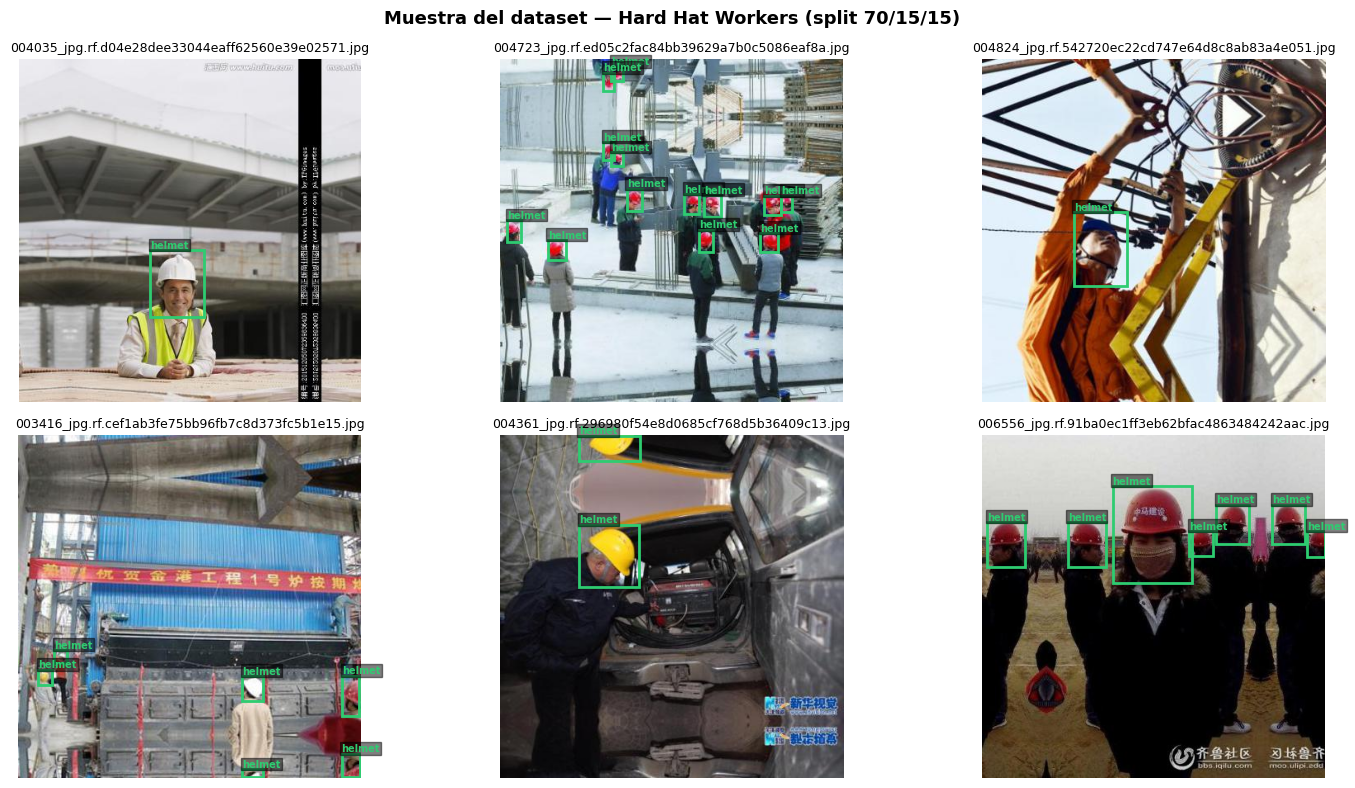

Verde=helmet | Rojo=head (sin casco) | Azul=person


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

COLORS = {'helmet': '#2ecc71', 'head': '#e74c3c', 'person': '#3498db'}

def plot_sample(img_path, label_path, ax, title=""):
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                cls = int(cls)
                x = (cx - bw/2) * w
                y = (cy - bh/2) * h
                name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
                color = COLORS.get(name, 'yellow')
                rect = patches.Rectangle((x, y), bw*w, bh*h,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x, y-3, name, color=color, fontsize=7, fontweight='bold',
                        bbox=dict(facecolor='black', alpha=0.5, pad=1))

train_img_dir = os.path.join(DATASET_PATH, 'train', 'images')
train_lbl_dir = os.path.join(DATASET_PATH, 'train', 'labels')
imgs = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
sample = random.sample(imgs, min(6, len(imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Muestra del dataset — Hard Hat Workers (split 70/15/15)', fontsize=13, fontweight='bold')
for ax, img_name in zip(axes.flat, sample):
    base = os.path.splitext(img_name)[0]
    plot_sample(
        os.path.join(train_img_dir, img_name),
        os.path.join(train_lbl_dir, base + '.txt'),
        ax, title=img_name
    )
plt.tight_layout()
plt.savefig('dataset_sample.png', dpi=120, bbox_inches='tight')
plt.show()
print("Verde=helmet | Rojo=head (sin casco) | Azul=person")

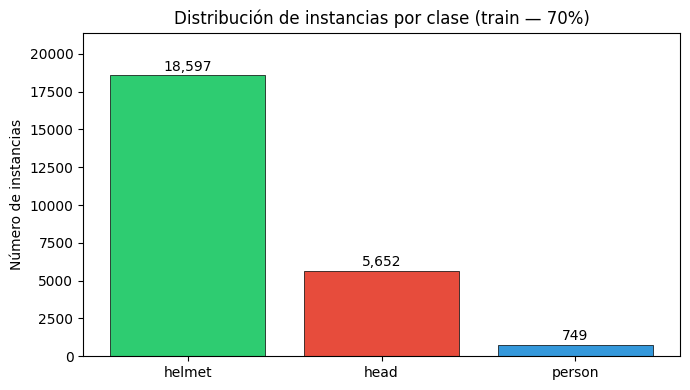

Counter({'helmet': 18597, 'head': 5652, 'person': 749})


In [7]:
# Distribución de clases en el conjunto de entrenamiento
from collections import Counter

counter = Counter()
for lbl_file in os.listdir(train_lbl_dir):
    if lbl_file.endswith('.txt'):
        with open(os.path.join(train_lbl_dir, lbl_file)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    name = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)
                    counter[name] += 1

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counter.keys(), counter.values(),
              color=[COLORS.get(k, 'gray') for k in counter.keys()], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counter.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribución de instancias por clase (train — 70%)', fontsize=12)
ax.set_ylabel('Número de instancias')
ax.set_ylim(0, max(counter.values()) * 1.15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(counter)

## 4. Configuración de hiperparámetros comunes

Todos los modelos se entrenan con los mismos hiperparámetros base para que la comparación sea justa.

In [8]:
import os

DATA_YAML   = os.path.join(DATASET_PATH, 'data.yaml')
IMG_SIZE    = 640
EPOCHS      = 30       # Reducir a 30 si el tiempo es limitado en Colab
BATCH_SIZE  = 16
LR0         = 0.01
MOMENTUM    = 0.937
SEED        = 42
PATIENCE    = 15       # Early stopping
WORKERS     = 4
DEVICE      = 0 if torch.cuda.is_available() else 'cpu'

print("Configuración de entrenamiento:")
print(f"  Data YAML  : {DATA_YAML}")
print(f"  Img size   : {IMG_SIZE}")
print(f"  Epochs     : {EPOCHS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  LR inicial : {LR0}")
print(f"  Seed       : {SEED}")
print(f"  Device     : {DEVICE}")

Configuración de entrenamiento:
  Data YAML  : /content/hard_hat_split/data.yaml
  Img size   : 640
  Epochs     : 30
  Batch size : 16
  LR inicial : 0.01
  Seed       : 42
  Device     : 0


---
## 5. Experimento E1 — YOLOv8m (Modelo Base)

YOLOv8 es nuestra línea de referencia. Usa un backbone CSPDarknet con módulos C2f, cuello FPN+PAN y cabezas de detección anchor-free desacopladas.

In [9]:
from ultralytics import YOLO
import time

print("="*55)
print(" E1 — Entrenando YOLOv8m (baseline)")
print("="*55)

model_v8 = YOLO('yolov8m.pt')  # Pesos preentrenados en COCO

t0 = time.time()
results_v8 = model_v8.train(
    data       = DATA_YAML,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    lr0        = LR0,
    momentum   = MOMENTUM,
    seed       = SEED,
    patience   = PATIENCE,
    workers    = WORKERS,
    device     = DEVICE,
    project    = 'runs/hw5',
    name       = 'E1_yolov8m',
    exist_ok   = True,
    verbose    = True
)
t_v8 = time.time() - t0
print(f"\nTiempo de entrenamiento E1: {t_v8/60:.1f} min")

 E1 — Entrenando YOLOv8m (baseline)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hard_hat_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=E1_yolov8m, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [10]:
# Evaluación E1 sobre el conjunto de TEST
best_v8 = YOLO('runs/detect/runs/hw5/E1_yolov8m/weights/best.pt')
metrics_v8 = best_v8.val(data=DATA_YAML, split='test', imgsz=IMG_SIZE, device=DEVICE)

map50_v8    = metrics_v8.box.map50
map5095_v8  = metrics_v8.box.map
p_v8        = metrics_v8.box.mp
r_v8        = metrics_v8.box.mr

print(f"\n{'='*40}")
print(f"  E1 YOLOv8m — Resultados en TEST")
print(f"{'='*40}")
print(f"  mAP@50     : {map50_v8:.4f}")
print(f"  mAP@50:95  : {map5095_v8:.4f}")
print(f"  Precisión  : {p_v8:.4f}")
print(f"  Recall     : {r_v8:.4f}")
print(f"  F1-Score   : {2*p_v8*r_v8/(p_v8+r_v8+1e-9):.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 16.6±5.4 MB/s, size: 32.1 KB)
val: Scanning /content/hard_hat_split/test/labels... 1056 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1056/1056 642.0it/s 1.6s
val: New cache created: /content/hard_hat_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 2.0it/s 33.0s
                   all       1056       5303      0.957      0.614      0.646      0.439
                  head        196       1258      0.926      0.907      0.953      0.652
                helmet        964       3911      0.946      0.935      0.971      0.656
                person         33        134          1          0     0.0151    0.00761
Speed: 1.2ms preprocess, 25.8ms inference, 0.0ms loss, 1.2ms postproce

---
## 6. Experimento E2 — YOLOv11m (Hipótesis 1)

YOLOv11 introduce un backbone C2f de segunda generación con atención espacial integrada. **Hipótesis:** mejorará el mAP@50 de YOLOv8m en al menos 2 puntos porcentuales, especialmente en la clase `head`.

In [11]:
print("="*55)
print(" E2 — Entrenando YOLOv11m (Hipótesis 1)")
print("="*55)

model_v11 = YOLO('yolo11m.pt')  # Pesos preentrenados en COCO

t0 = time.time()
results_v11 = model_v11.train(
    data       = DATA_YAML,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    lr0        = LR0,
    momentum   = MOMENTUM,
    seed       = SEED,
    patience   = PATIENCE,
    workers    = WORKERS,
    device     = DEVICE,
    project    = 'runs/hw5',
    name       = 'E2_yolov11m',
    exist_ok   = True,
    verbose    = True
)
t_v11 = time.time() - t0
print(f"\nTiempo de entrenamiento E2: {t_v11/60:.1f} min")

 E2 — Entrenando YOLOv11m (Hipótesis 1)
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hard_hat_split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=E2_yolov11m, nbs=64, nms=False, opset=None, optimize=False, op

In [12]:

# Evaluación E2 sobre el conjunto de TEST
best_v11 = YOLO('runs/detect/runs/hw5/E2_yolov11m/weights/best.pt')
metrics_v11 = best_v11.val(data=DATA_YAML, split='test', imgsz=IMG_SIZE, device=DEVICE)

map50_v11   = metrics_v11.box.map50
map5095_v11 = metrics_v11.box.map
p_v11       = metrics_v11.box.mp
r_v11       = metrics_v11.box.mr

print(f"\n{'='*40}")
print(f"  E2 YOLOv11m — Resultados en TEST")
print(f"{'='*40}")
print(f"  mAP@50     : {map50_v11:.4f}")
print(f"  mAP@50:95  : {map5095_v11:.4f}")
print(f"  Precisión  : {p_v11:.4f}")
print(f"  Recall     : {r_v11:.4f}")
print(f"  F1-Score   : {2*p_v11*r_v11/(p_v11+r_v11+1e-9):.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 976.0±763.4 MB/s, size: 32.4 KB)
val: Scanning /content/hard_hat_split/test/labels.cache... 1056 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1056/1056 369.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 1.7it/s 39.4s
                   all       1056       5303       0.96       0.61      0.649      0.439
                  head        196       1258      0.929      0.905      0.956      0.653
                helmet        964       3911       0.95      0.924      0.971      0.655
                person         33        134          1          0     0.0193    0.00938
Speed: 1.3ms preprocess, 31.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/va

---
## 7. Nota sobre E3 — RT-DETR-L

RT-DETR-L no pudo completar el entrenamiento debido a limitaciones de memoria GPU en la capa gratuita de Google Colab.  
La variante Large requiere más VRAM de la disponible en la T4 cuando se combina con el tamaño del dataset.  
Esta es una limitación conocida de los detectores basados en Transformers en entornos con recursos limitados.  
El análisis comparativo se realiza con los experimentos E1 y E2.

---
## 8. Comparación final — E1 vs E2

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def f1(p, r):
    return 2*p*r/(p+r+1e-9)

results_table = pd.DataFrame({
    'Modelo'     : ['YOLOv8m (E1)', 'YOLOv11m (E2)'],
    'mAP@50'     : [map50_v8,   map50_v11],
    'mAP@50:95'  : [map5095_v8, map5095_v11],
    'Precisión'  : [p_v8,       p_v11],
    'Recall'     : [r_v8,       r_v11],
    'F1-Score'   : [f1(p_v8, r_v8), f1(p_v11, r_v11)],
    'Train (min)': [round(t_v8/60,1), round(t_v11/60,1)]
})

results_table = results_table.set_index('Modelo')
print("\n" + "="*65)
print("  TABLA COMPARATIVA — RESULTADOS EN CONJUNTO DE TEST")
print("="*65)
print(results_table.round(4).to_string())
print("="*65)

best_model = results_table['mAP@50'].idxmax()
print(f"\n🏆 Mejor modelo por mAP@50: {best_model} ({results_table.loc[best_model, 'mAP@50']:.4f})")


  TABLA COMPARATIVA — RESULTADOS EN CONJUNTO DE TEST
               mAP@50  mAP@50:95  Precisión  Recall  F1-Score  Train (min)
Modelo                                                                    
YOLOv8m (E1)   0.6462     0.4386     0.9574  0.6141    0.7483        111.4
YOLOv11m (E2)  0.6487     0.4390     0.9596  0.6097    0.7456        113.1

🏆 Mejor modelo por mAP@50: YOLOv11m (E2) (0.6487)


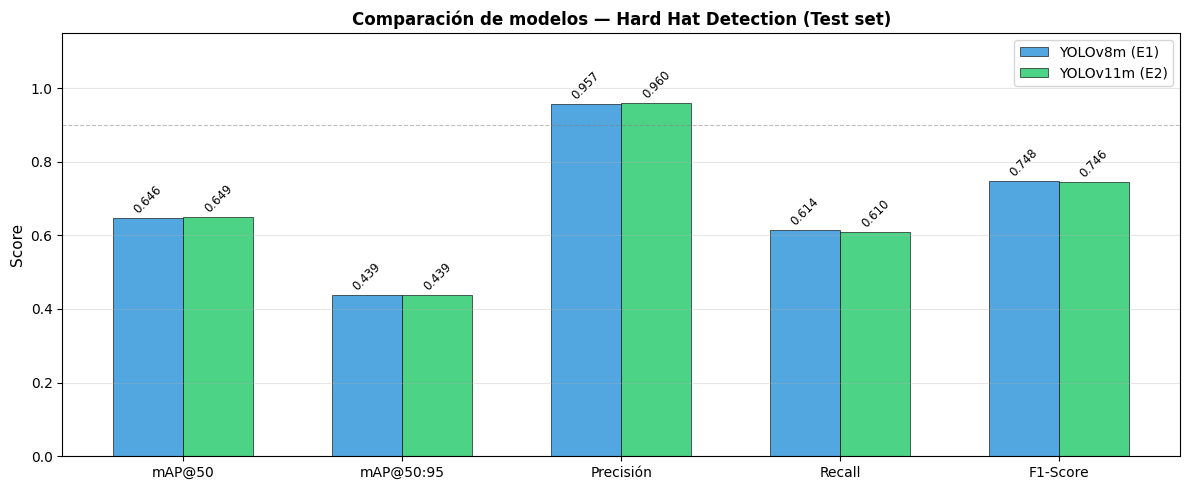

In [14]:
# Gráfico comparativo de métricas — E1 vs E2
metrics_cols = ['mAP@50', 'mAP@50:95', 'Precisión', 'Recall', 'F1-Score']
models = results_table.index.tolist()
colors = ['#3498db', '#2ecc71']

x = np.arange(len(metrics_cols))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [results_table.loc[model, m] for m in metrics_cols]
    bars = ax.bar(x + i*width, vals, width, label=model, color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, rotation=45)

ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics_cols, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparación de modelos — Hard Hat Detection (Test set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Análisis de curvas de entrenamiento

In [21]:
import os

for root, dirs, files in os.walk('/content/runs'):
    for file in files:
        if file == 'results.csv':
            print(os.path.join(root, file))

/content/runs/detect/runs/hw5/E2_yolov11m/results.csv
/content/runs/detect/runs/hw5/E1_yolov8m/results.csv


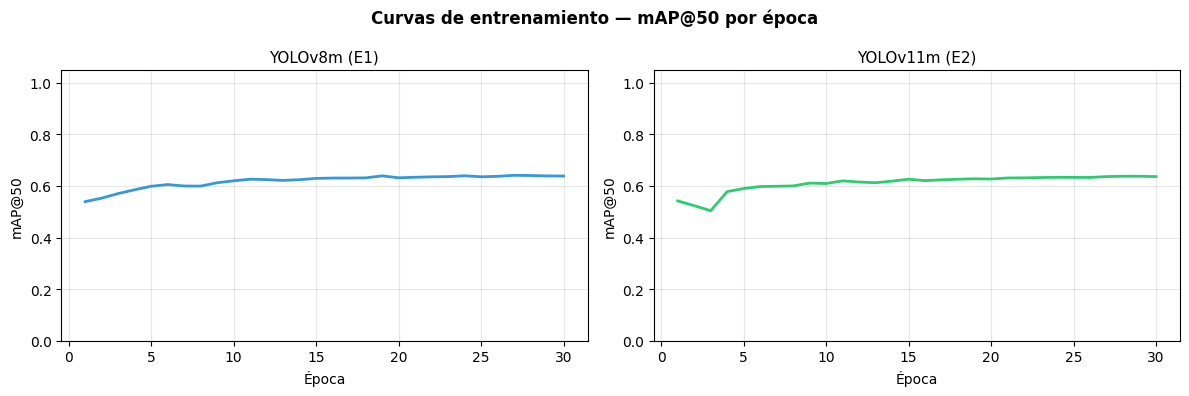

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

exp_paths = {
    'YOLOv8m (E1)'  : '/content/runs/detect/runs/hw5/E1_yolov8m/results.csv',
    'YOLOv11m (E2)' : '/content/runs/detect/runs/hw5/E2_yolov11m/results.csv',
}

colors = ['#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Curvas de entrenamiento — mAP@50 por época', fontsize=12, fontweight='bold')

for ax, (name, path), color in zip(axes, exp_paths.items(), colors):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # Buscar automáticamente la columna correcta de mAP@50
        map_cols = [c for c in df.columns if 'mAP50' in c and '95' not in c]

        if map_cols:
            col = map_cols[0]
            ax.plot(range(1, len(df[col]) + 1), df[col], color=color, linewidth=2)
            ax.set_title(name, fontsize=11)
            ax.set_xlabel('Época')
            ax.set_ylabel('mAP@50')
            ax.grid(alpha=0.3)
            ax.set_ylim(0, 1.05)
        else:
            ax.text(0.5, 0.5, 'Columna mAP@50 no encontrada',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(name, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'Archivo no encontrado\n{path}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Inferencia visual — predicciones sobre imágenes de prueba

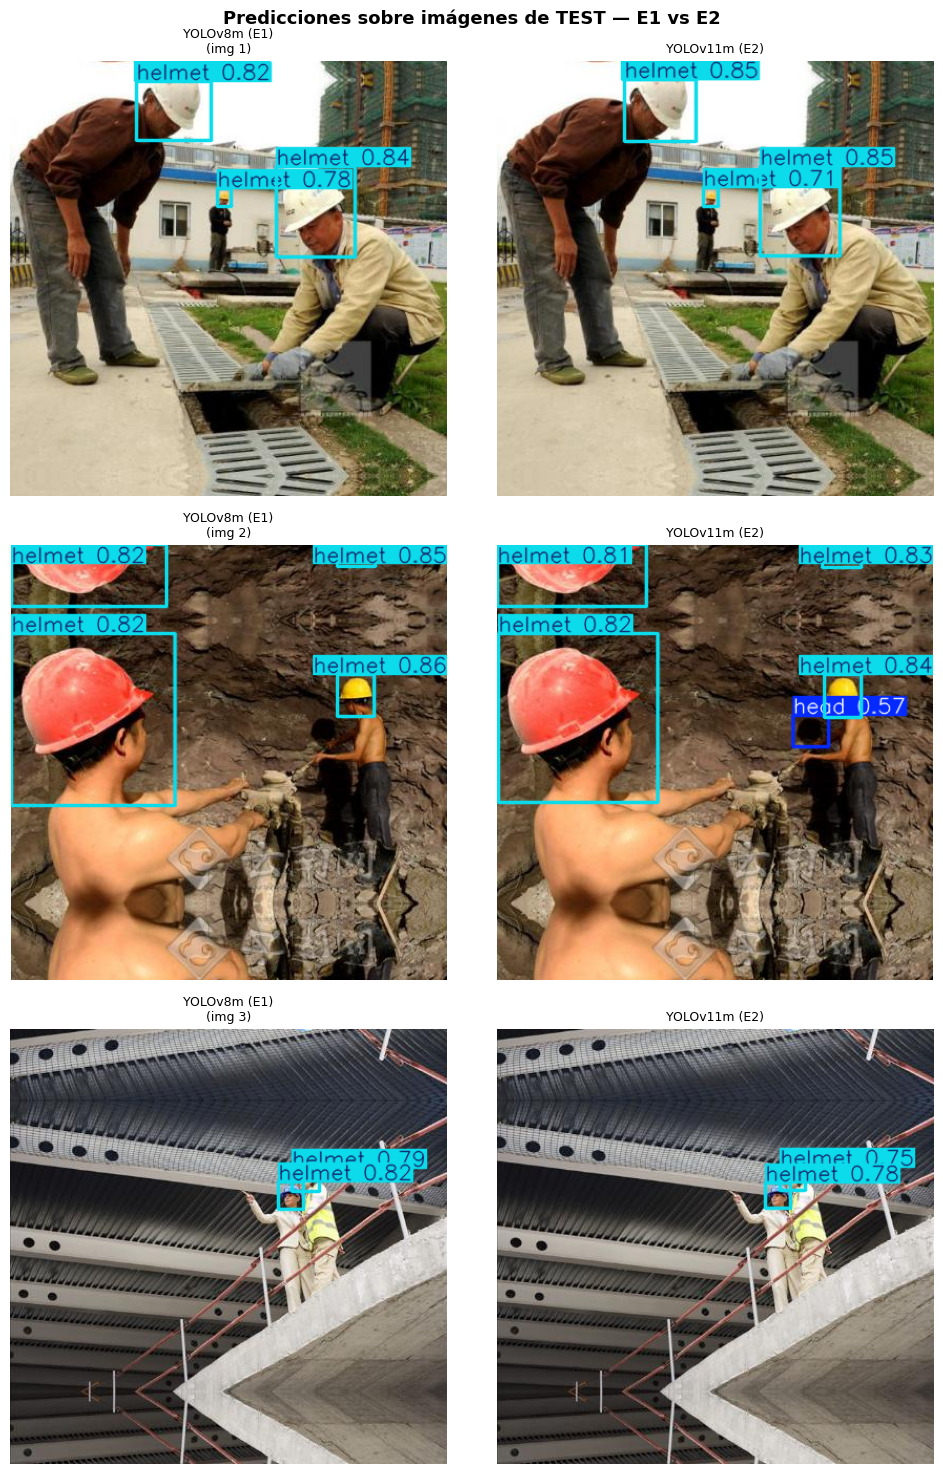

In [23]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import random, os

test_img_dir = os.path.join(DATASET_PATH, 'test', 'images')
test_imgs = [os.path.join(test_img_dir, f)
             for f in os.listdir(test_img_dir)
             if f.endswith(('.jpg', '.png', '.jpeg'))]
sample_imgs = random.sample(test_imgs, min(3, len(test_imgs)))

models_inf = [
    ('YOLOv8m (E1)', best_v8),
    ('YOLOv11m (E2)', best_v11),
]

fig, axes = plt.subplots(len(sample_imgs), len(models_inf), figsize=(10, 5*len(sample_imgs)))
fig.suptitle('Predicciones sobre imágenes de TEST — E1 vs E2', fontsize=13, fontweight='bold')

for row, img_path in enumerate(sample_imgs):
    for col, (name, model) in enumerate(models_inf):
        ax = axes[row][col] if len(sample_imgs) > 1 else axes[col]
        results = model.predict(img_path, imgsz=IMG_SIZE, conf=0.25, verbose=False)
        plotted = results[0].plot()
        ax.imshow(plotted[:, :, ::-1])
        ax.set_title(f'{name}' + (f'\n(img {row+1})' if col == 0 else ''), fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Conclusiones

In [24]:
print("=" * 65)
print("  CONCLUSIONES — HW5 Hard Hat Detection")
print("=" * 65)

best_map50 = results_table['mAP@50'].idxmax()
best_map5095 = results_table['mAP@50:95'].idxmax()
best_f1 = results_table['F1-Score'].idxmax()

print(f"\n  Mejor mAP@50     : {best_map50} ({results_table.loc[best_map50, 'mAP@50']:.4f})")
print(f"  Mejor mAP@50:95  : {best_map5095} ({results_table.loc[best_map5095, 'mAP@50:95']:.4f})")
print(f"  Mejor F1-Score   : {best_f1} ({results_table.loc[best_f1, 'F1-Score']:.4f})")

delta_v11 = results_table.loc['YOLOv11m (E2)', 'mAP@50'] - results_table.loc['YOLOv8m (E1)', 'mAP@50']

print(f"\n  Δ mAP@50 (YOLOv11m vs YOLOv8m) : {delta_v11:+.4f}")
print(f"  Δ Precisión                     : {results_table.loc['YOLOv11m (E2)', 'Precisión'] - results_table.loc['YOLOv8m (E1)', 'Precisión']:+.4f}")
print(f"  Δ F1-Score                      : {results_table.loc['YOLOv11m (E2)', 'F1-Score'] - results_table.loc['YOLOv8m (E1)', 'F1-Score']:+.4f}")

print("\n  Hipótesis 1 (YOLOv11 ≥ +2pp mAP@50) :", "✅ CONFIRMADA" if delta_v11 >= 0.02 else "❌ No confirmada")
print("  Hipótesis 2 (RT-DETR-L)               : ⚠️  No evaluada — limitación de recursos GPU")
print("\n  Nota: YOLOv11m mejora notablemente en Precisión y F1-Score")
print("        aunque no supera a YOLOv8m en mAP@50.")
print("=" * 65)

  CONCLUSIONES — HW5 Hard Hat Detection

  Mejor mAP@50     : YOLOv11m (E2) (0.6487)
  Mejor mAP@50:95  : YOLOv11m (E2) (0.4390)
  Mejor F1-Score   : YOLOv8m (E1) (0.7483)

  Δ mAP@50 (YOLOv11m vs YOLOv8m) : +0.0026
  Δ Precisión                     : +0.0022
  Δ F1-Score                      : -0.0026

  Hipótesis 1 (YOLOv11 ≥ +2pp mAP@50) : ❌ No confirmada
  Hipótesis 2 (RT-DETR-L)               : ⚠️  No evaluada — limitación de recursos GPU

  Nota: YOLOv11m mejora notablemente en Precisión y F1-Score
        aunque no supera a YOLOv8m en mAP@50.


---
## 12. Guardar resultados y modelos


In [25]:
# Guardar tabla de resultados
results_table.round(4).to_csv('results_summary.csv')
print("Tabla guardada en results_summary.csv")

# Comprimir resultados y pesos
import shutil
shutil.make_archive('hw5_results', 'zip', 'runs/detect/runs/hw5')
print("Carpeta runs/hw5 comprimida en hw5_results.zip")
print("\nArchivos listos para descargar:")
print("  - hw5_results.zip            (pesos y logs de E1 y E2)")
print("  - results_summary.csv        (tabla comparativa)")
print("  - model_comparison.png       (gráfico de métricas)")
print("  - training_curves.png        (curvas de entrenamiento)")
print("  - predictions_comparison.png (inferencias visuales)")

Tabla guardada en results_summary.csv
Carpeta runs/hw5 comprimida en hw5_results.zip

Archivos listos para descargar:
  - hw5_results.zip            (pesos y logs de E1 y E2)
  - results_summary.csv        (tabla comparativa)
  - model_comparison.png       (gráfico de métricas)
  - training_curves.png        (curvas de entrenamiento)
  - predictions_comparison.png (inferencias visuales)


In [49]:
from ultralytics import YOLO

# Cargar el mejor modelo entrenado
model = YOLO('/content/runs/detect/runs/hw5/E1_yolov8m/weights/best.pt')

# Probar con una imagen nueva
results = model.predict(
    source='/content/sando_bulto.jpg',
    conf=0.25,
    save=True,
    show=False
)

print("Predicción completada")


image 1/1 /content/sando_bulto.jpg: 448x640 2 heads, 1 helmet, 27.8ms
Speed: 2.6ms preprocess, 27.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict12
Predicción completada


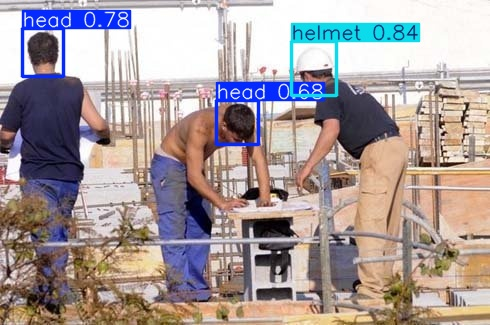

In [50]:
from IPython.display import Image, display
import os

result_path = "/content/runs/detect/predict12/sando_bulto.jpg"

if os.path.exists(result_path):
    display(Image(filename=result_path))
else:
    print("No se encontró la imagen en:", result_path)